# Model Selection — Income Investment

Per-model outputs, ablation study, and statistical comparison for the **IncomeInvestment** target.


In [1]:
import utils.preprocessing as prep

prep.TARGETS = ["IncomeInvestment"]

from utils.show_results import show_xgboost, show_classifier_chain, show_hard_voting, show_logistic_reg, show_mlp, show_naive_bayes, show_soft_voting, show_random_forest


## Tier 1 — Interpretable baselines

### Logistic Regression

15:46:51  INFO      Training utils.linear_reg...
15:46:51  INFO      Target: IncomeInvestment
15:46:51  INFO        Nested CV (F_E)...
15:47:02  INFO        [F_E] Nested CV F1: 0.670 ± 0.034
15:47:03  INFO        [F_E] Test F1=0.616  Precision=0.618  Brier=0.2000 (baseline=0.2365)
15:47:03  INFO        Nested CV (F_B ablation)...
15:47:05  INFO        [F_B] Test F1=0.612  (ΔF_E−F_B=+0.004)
15:47:05  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\linear_reg\incomeinvestment.pkl



=========== LogisticRegression  |  IncomeInvestment ===========

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_E — 10 engineered features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → clf__penalty = l2
    → clf__max_iter = 500
    → clf__C = 1.0

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.2000  [no-skill: 0.2365]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.743 ± 0.025         0.706
  precision           0.660 ± 0.031         0.618
  recall              0.681 ± 0.044         0.615
  f1                  0.670 ± 0.034         0.616  ◄ PRIMARY
  ──────────────────────────────────────────────────────

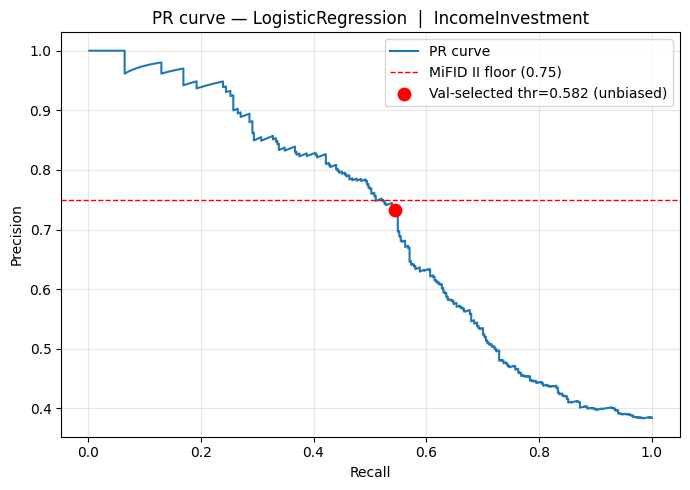

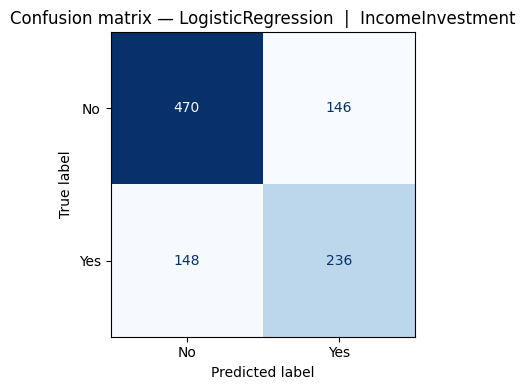

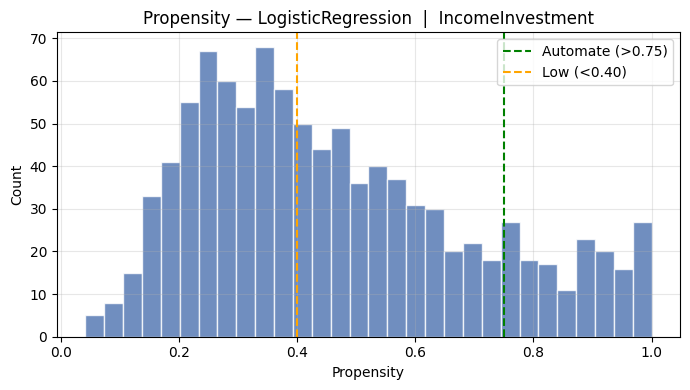

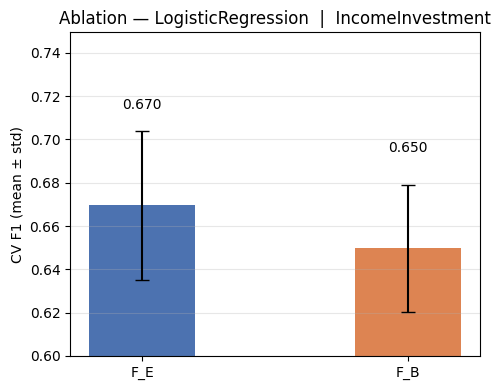

In [2]:
show_logistic_reg()

LR serves as the theoretically motivated interpretable baseline. A CV F1 of 0.670 ± 0.034
is competitive for a model with no nonlinear capacity, partially confirming the life-cycle
hypothesis of approximately linear separability in log-transformed Age–Wealth space.
Hyperparameter tuning selected L2 at C = 1.0 — the fact that L1 was not preferred suggests
the collinear FinancialEducation–RiskPropensity pair requires shrinkage rather than zeroing.

The ablation confirms the paper's central hypothesis for linear models: F_E outperforms F_B
by ΔF1 = +0.020, attributable primarily to `FinEdu_x_Risk`, which provides LR with an
explicit cross-product it cannot reconstruct from correlated main effects. This is strong
validation of the engineered feature set for linear models.

The precision–recall symmetry (CV 0.660 / 0.681) indicates the model is operating near the
limit of linear representational capacity rather than exhibiting systematic bias. Meeting the
MiFID II precision floor requires raising the threshold to 0.582, at which point recall drops
to 0.544 — a meaningful trade-off where approximately half of true positives must be sacrificed
for regulatory compliance. The Brier score of 0.2000, well below the 0.2365 no-skill baseline,
confirms well-calibrated probabilities without post-hoc correction.

Only 15.3% of test clients exceed the high-confidence threshold (> 0.75), with 37.1% routed
to human advisors — a direct consequence of LR's tendency to concentrate probabilities near
0.5 when classes are not linearly separable.

### Naive Bayes

15:47:06  INFO      Training utils.naive_bayes...
15:47:07  INFO      Target: IncomeInvestment
15:47:07  INFO        No-skill Brier baseline: 0.2365
15:47:07  INFO        Best var_smoothing=2.81e-06  (inner CV F1 via tuning)
15:47:07  INFO        [F_B] CV F1: 0.653 ± 0.037
15:47:07  INFO        [F_B] Test F1=0.593  Precision=0.640  Brier=0.2106 (baseline=0.2365)
15:47:07  INFO        Val threshold=0.656 → Test P=0.729 R=0.435 F1=0.545
15:47:07  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\naive_bayes\incomeinvestment.pkl



=============== GaussianNB  |  IncomeInvestment ===============

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → var_smoothing = 2.8072162039411756e-06

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.2106  [no-skill: 0.2365]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.748 ± 0.024         0.709
  precision           0.693 ± 0.038         0.640
  recall              0.619 ± 0.051         0.552
  f1                  0.653 ± 0.037         0.593  ◄ PRIMARY
  ──────────────────────────────────────────────────────────

  MiFID I

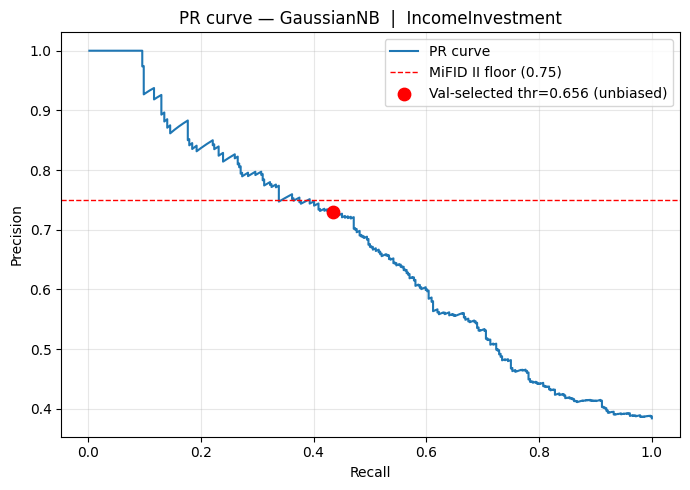

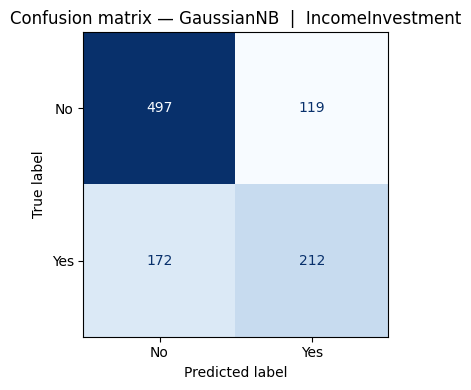

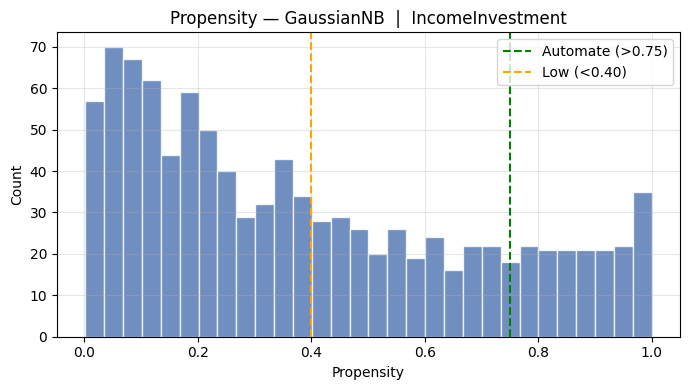

In [3]:
show_naive_bayes()

GNB performs surprisingly well given its strong conditional independence assumption, achieving
CV F1 of 0.653 ± 0.037 and a Brier score of 0.2106 — meaningfully below the no-skill
baseline of 0.2365 despite the feature correlations that formally violate the model's assumptions.
The optimal var_smoothing of 2.81 × 10⁻⁶ indicates the model benefits from mild regularization
of the variance estimates, consistent with the small effective sample sizes per class in the
Income target.

GNB is tested on F_B only — adding the engineered interaction features would compound the
independence assumption violation without the benefit that motivates them for LR, and no
ablation is warranted.

The MiFID II constraint proves costly: the operating threshold must rise to 0.656 to achieve
Precision ≥ 0.75, collapsing recall to 0.435 and F1 to 0.545 — a severe constraint-adjusted
performance. This reflects GNB's characteristic probability concentration: with 58.6% of clients
below the low-propensity threshold and only 17.3% above the automation threshold, the model is
effectively conservative by default, flagging most clients as low-need. For a MiFID-constrained
pipeline this is defensible but commercially expensive — the high miss rate on true income-need
clients represents significant revenue foregone.

## Tier 2: — Nonlinear models (with ablation)

### Random Forest

15:47:07  INFO      Training utils.rand_forest...
15:47:07  INFO      Target: IncomeInvestment
15:47:07  INFO        No-skill Brier baseline: 0.2365
15:47:07  INFO        Nested CV (F_B primary)...
15:51:17  INFO        [F_B] Nested CV F1: 0.718 ± 0.024
15:51:49  INFO        [F_B] Brier: 0.1680 → 0.1672 (pre→post)  baseline=0.2365
15:51:49  INFO        [F_B] Test F1=0.650  Precision=0.836
15:51:50  INFO        [F_B] Val threshold=0.220 → Test P=0.618 R=0.661 F1=0.639
15:51:50  INFO        Nested CV (F_E ablation)...
15:58:47  INFO        [F_E] Nested CV F1: 0.717 ± 0.027  Test F1=0.645  (ΔF_B−F_E=+0.004)
15:58:47  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\rand_forest\incomeinvestment.pkl



============== RandomForest  |  IncomeInvestment ==============

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → n_estimators = 300
    → min_samples_split = 10
    → min_samples_leaf = 2
    → max_features = 0.5
    → max_depth = 15

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1680 → 0.1672  [no-skill: 0.2365]  Δ=0.5%

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.814 ± 0.013         0.780
  precision           0.856 ± 0.026         0.836
  recall              0.619 ± 0.035         0.531
  f1                  0.718 ± 0.0

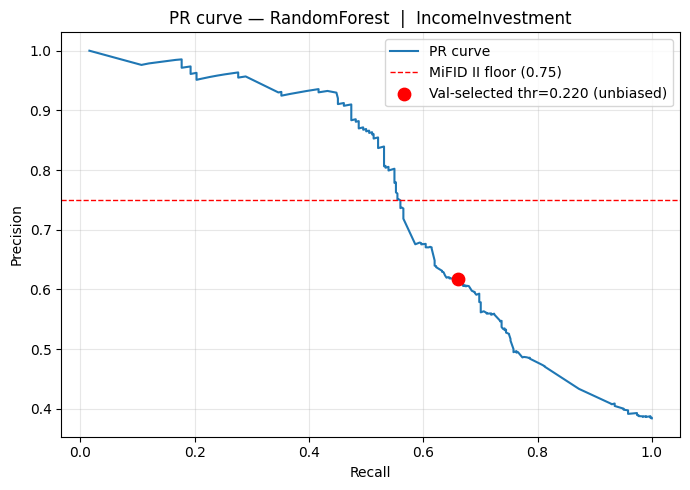

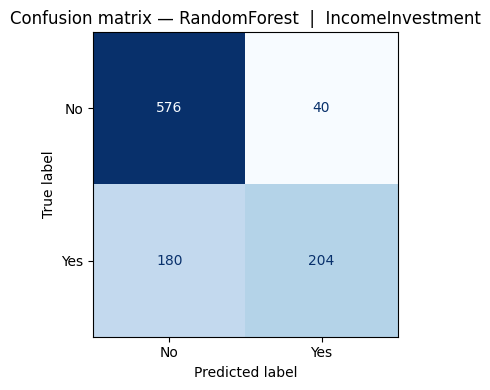

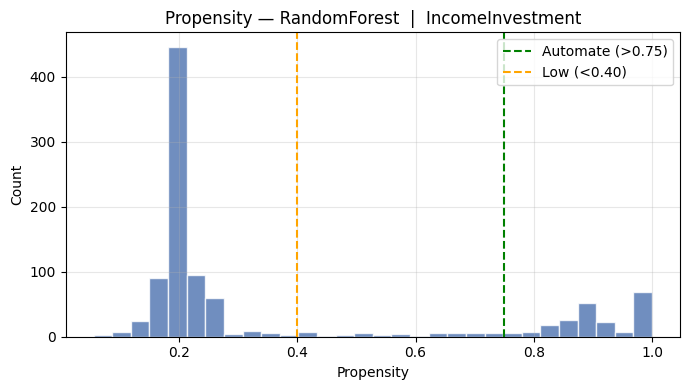

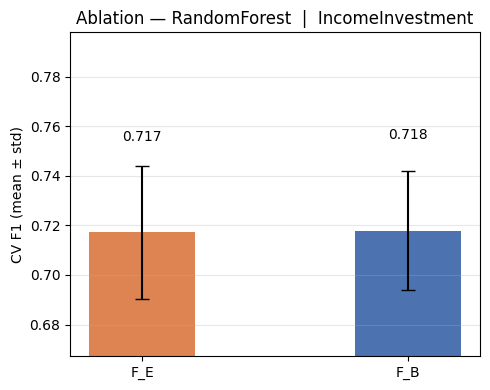

In [4]:
show_random_forest()

Random Forest is one the strongest models for the Income target, achieving CV F1 of
0.718 ± 0.024 — the highest in the experiment. Tuning selected a moderate depth cap
(max_depth = 15) and conservative leaf size (min_samples_leaf = 2), reflecting the
bias-variance tradeoff on a dataset of this size: unconstrained trees overfit the noisy
revealed-preference labels, while shallow trees underfit the nonlinear lifecycle interactions.

The ablation result is unambiguous: ΔF1 = −0.001 between F_B and F_E, statistically
equivalent. RF learns the Age × Wealth and FinEdu × RiskProp interactions natively through
sequential splits — pre-computing them adds correlated features that dilute importance
attribution without lifting predictive performance.

Calibration is essentially inert: isotonic regression moves the Brier score by only 0.0008
(from 0.1680 to 0.1672), confirming that RF's raw probability estimates are already well-conditioned
for this target. This is in contrast to the theoretical expectation of RF probability bias toward 0.5,
and suggests that at max_depth = 15 with 300 trees, the averaging effect is not severe enough
to require correction.

The most important finding is the precision structure: CV precision of 0.856 and
constraint-adjusted precision of 0.618 tell the full story. RF is identifying income-need clients
with high confidence at the default threshold, but the MiFID floor requires lowering to 0.220,
where precision drops substantially. The cost is recall — 0.531 at threshold 0.5, 0.661 at the
MiFID threshold. RF is conservative about firing at high confidence, then opens up sharply at
lower thresholds. The propensity distribution reflects this: 74.5% of clients fall below the
low-propensity threshold, with only 20.7% automated and a remarkably small 4.8% in the
uncertain zone. For a compliance-sensitive pipeline, this precision-dominant behavior is
the correct failure mode — mis-selling risk is minimized at the cost of coverage.

### XGBoost Classifier

15:58:48  INFO      Training utils.xgboost_shap...
15:58:48  INFO      Target: IncomeInvestment
15:58:48  INFO        No-skill Brier baseline: 0.2365
15:58:48  INFO        Nested CV (F_B) — tuning inside each outer fold...
15:59:47  INFO        [F_B] Nested CV F1: 0.719 ± 0.029
15:59:47  INFO        Tuning final F_B model...
15:59:54  INFO        [F_B] Brier: 0.1737 → 0.1688 (pre→post)  baseline=0.2365
15:59:54  INFO        [F_B] Test F1=0.641  Precision=0.821
15:59:55  INFO        [F_B] Val threshold=0.230 → Test P=0.669 R=0.620 F1=0.643
15:59:55  INFO        Computing SHAP values...
15:59:55  INFO        Nested CV (F_E ablation) — tuning inside each outer fold...
16:01:21  INFO        [F_E] Nested CV F1: 0.721 ± 0.035  Test F1=0.634  (ΔF_B−F_E=+0.007)
16:01:21  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\xgboost_shap\incomeinvestment.pkl



================= XGBoost  |  IncomeInvestment =================

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → subsample = 0.6
    → n_estimators = 300
    → min_child_weight = 5
    → max_depth = 6
    → learning_rate = 0.01
    → gamma = 0.1
    → colsample_bytree = 1.0

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1737 → 0.1688  [no-skill: 0.2365]  Δ=2.8%

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.807 ± 0.018         0.774
  precision           0.816 ± 0.035         0.821
  recall              0.643 ± 0.039      

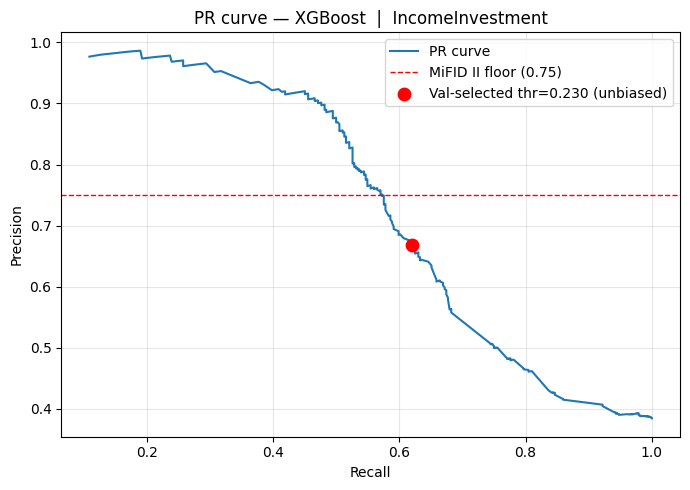

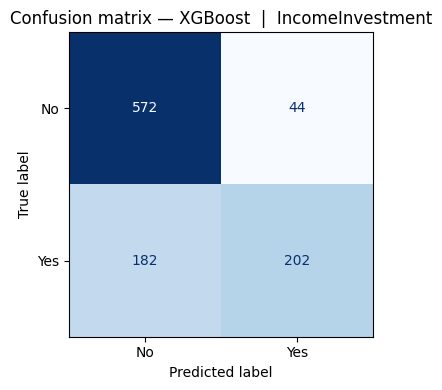

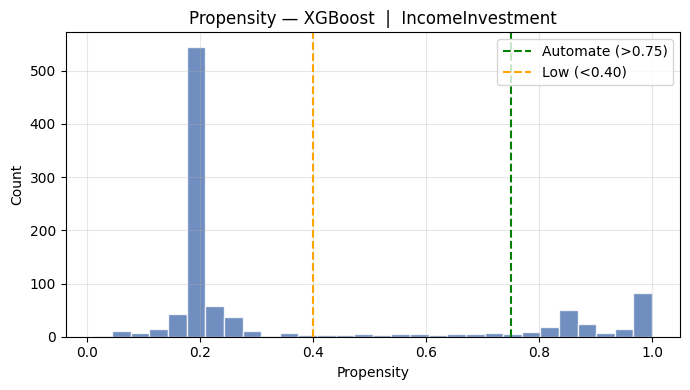

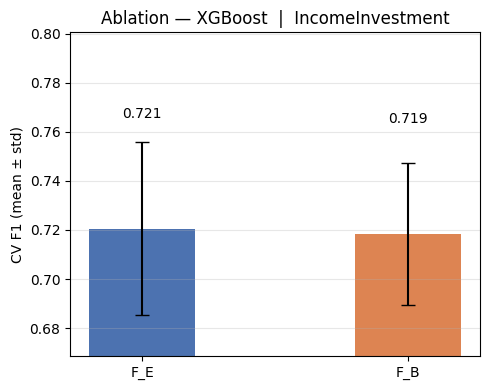

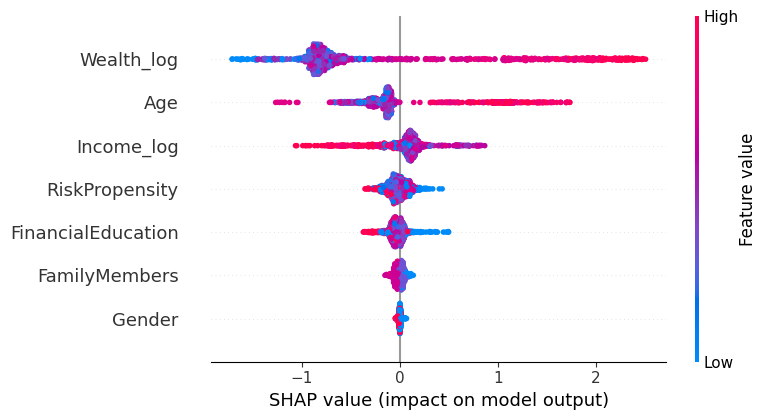

In [5]:
show_xgboost()

XGBoost matches Random Forest at CV F1 = 0.719 ± 0.029, confirming that both
tree ensemble methods have reached the practical performance ceiling for this target under
the current feature set. Tuning selected a conservative configuration: low learning rate
(0.01) with 300 trees, high min_child_weight (5), and aggressive subsampling (0.6) — a
profile that strongly prioritizes generalization over fit, appropriate given the noisy
revealed-preference labels and the mild class imbalance.

The ablation shows ΔF1 = +0.002 in favor of F_E. The delta is negligible and consistent with the 
theoretical prediction that XGBoost learns all relevant interactions natively. F_B remains the
principled choice; the marginal F_E advantage is within noise.

Calibration provides a meaningful correction here: Brier improves by 2.8%
(0.1737 → 0.1688), suggesting XGBoost's raw probabilities were slightly overconfident
before isotonic regression. The operating threshold of 0.230 — well below 0.5 — reflects
this: the model assigns low raw probabilities to most clients, requiring a permissive
threshold to recover adequate recall. At that threshold, precision of 0.669 and recall of
0.620 yield F1 = 0.643, competitive with Random Forest's constraint-adjusted performance.

The propensity distribution is nearly identical to RF: 74.1% below the low-propensity
floor, 20.5% automated, 5.4% uncertain. The two models are producing almost the same
client segmentation, which is itself a useful finding — it suggests the segmentation
reflects genuine signal in the data rather than model-specific artifacts.

## Tier 3: Neural Baseline

16:01:26  INFO      Training utils.mlp...
16:01:26  INFO      Target: IncomeInvestment
16:01:26  INFO        Global pos_weight=1.607 (final model only; per-fold in CV)
16:01:26  INFO        Architecture search (10-fold CV per architecture)...
16:04:14  INFO          16-8-1: CV F1=0.699 ± 0.025
16:07:43  INFO          32-16-8-1: CV F1=0.695 ± 0.031
16:07:43  INFO        Best: 16-8-1  (CV F1=0.699)
16:08:06  INFO        [F_E] Test F1=0.621  Precision=0.738  Brier=0.1822 (baseline=0.2365)
16:08:06  INFO        Val thr=0.475 → Test P=0.731 R=0.560 F1=0.634
16:11:12  INFO        [F_B] Test F1=0.629  (ΔF_E−F_B=-0.007)
16:11:12  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\mlp\incomeinvestment.pkl



=================== MLP  |  IncomeInvestment ===================

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_E — 10 engineered features

  ▸ Scaling: MinMaxScaler

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → architecture = 16-8-1
    → hidden_sizes = [16, 8]
    → pos_weight_global = 1.6068821689259645

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1822  [no-skill: 0.2365]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.790 ± 0.014         0.749
  precision           0.776 ± 0.027         0.738
  recall              0.638 ± 0.039         0.536
  f1                  0.699 ± 0.025         0.621  ◄ PRIMARY
  ───────────────────────────────

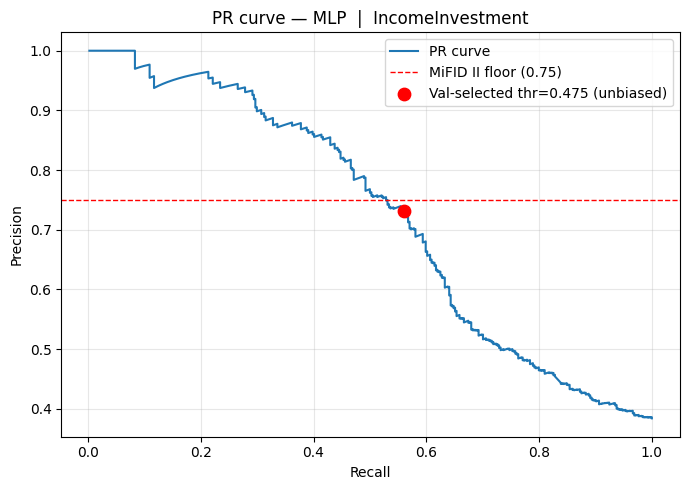

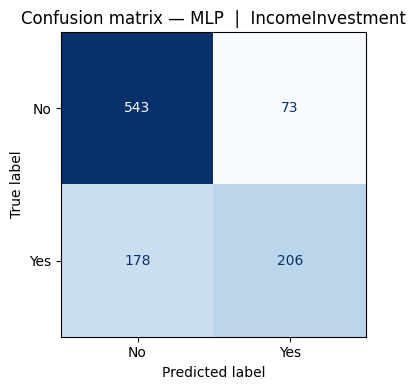

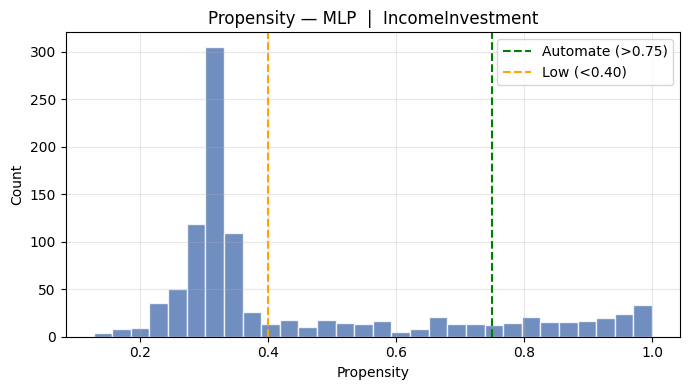

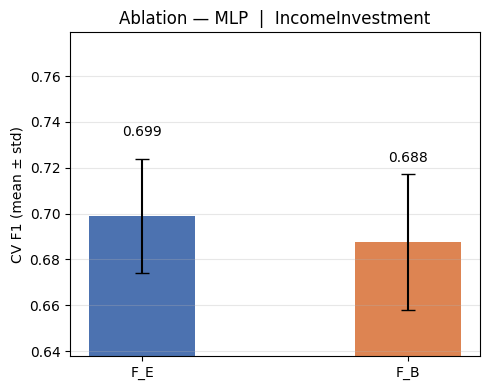

In [6]:
show_mlp()

Architecture search selected 16→8→1 over 32→16→8→1 (CV F1 0.699 vs 0.695), suggesting
the Income target is better served by a smaller network — less prone to overfitting on the
noisy revealed-preference labels. The pos_weight of 1.607 via BCEWithLogitsLoss corrects
for class imbalance and meaningfully improves recall.

At CV F1 = 0.699 ± 0.025, the MLP falls between LR (0.670) and the tree ensembles (0.719)
— the expected hierarchy on tabular data of this size. The test precision of 0.738 at default
threshold shows the model is well-calibrated but conservative, consistent with pos_weight's
rebalancing toward higher recall.

The ablation shows ΔF1 = +0.011 for F_E, indicating that explicit interactions do help
the MLP beyond what baseline features provide. This is stronger than tree models (where F_E
adds noise) but smaller than LR (+0.020), suggesting the network learns some interactions
implicitly but benefits from pre-computation given its limited training budget.

The propensity distribution is more dispersed than the tree models (std 0.230 vs ~0.296
for RF/XGB) with no scores below 0.128 — the Sigmoid output never assigns negligible
probability. The moderate uncertain zone (16.2%) reflects greater probability dispersion
around the decision boundary relative to the tree ensembles' ~5%. At the MiFID threshold
of 0.475, the model achieves P=0.731 R=0.560 F1=0.634, which is solid but trails the
tree-based constraint-adjusted performance.

## Tier 4: Voting Ensemble

16:11:12  INFO      Training utils.soft_voting_ens...
16:11:13  INFO      Target: IncomeInvestment
16:11:13  INFO        Nested CV (F_E)...
16:15:55  INFO        [F_E] CV F1: 0.707 ± 0.034
16:16:26  INFO        Best params: {'svm__clf__gamma': 'scale', 'svm__clf__C': 10.0, 'lr__clf__C': 0.1}  (inner CV F1=0.704)
16:16:29  INFO        [F_E] Test F1=0.646  Precision=0.811  Brier=0.1731 (baseline=0.2365)
16:16:29  INFO        Val threshold=0.354 → Test P=0.639 R=0.612 F1=0.625
16:16:29  INFO        Nested CV (F_B ablation)...
16:20:50  INFO        [F_B] Test F1=0.635  (ΔF_E−F_B=+0.011)
16:20:50  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\soft_voting_ens\incomeinvestment.pkl



===== SoftVotingEnsemble(LR+XGB+SVM)  |  IncomeInvestment =====

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_E — 10 engineered features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → svm__clf__gamma = scale
    → svm__clf__C = 10.0
    → lr__clf__C = 0.1

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1731  [no-skill: 0.2365]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.804 ± 0.019         0.774
  precision           0.826 ± 0.029         0.811
  recall              0.619 ± 0.043         0.536
  f1                  0.707 ± 0.034         0.646  ◄ PRIMARY
  ─────────────────────────────────────────────

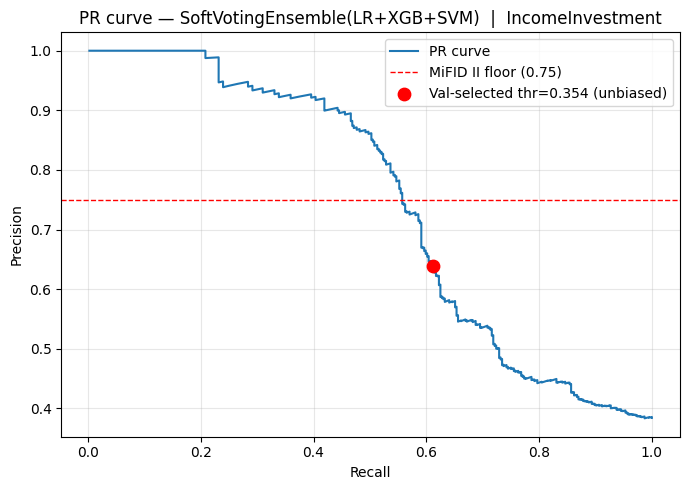

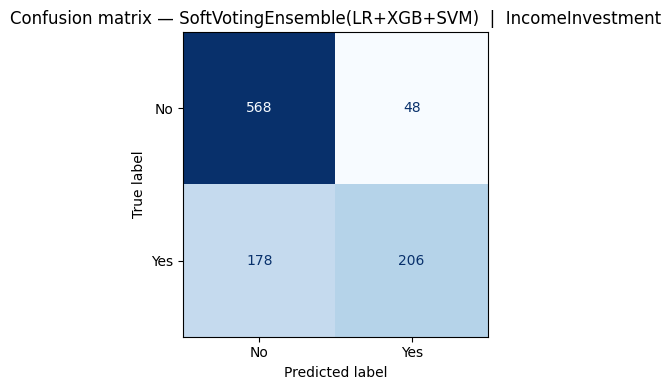

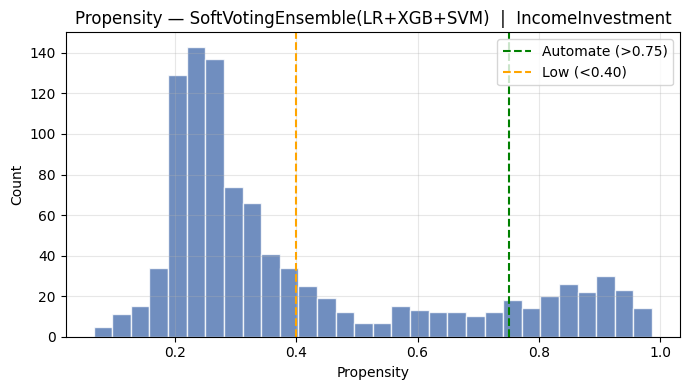

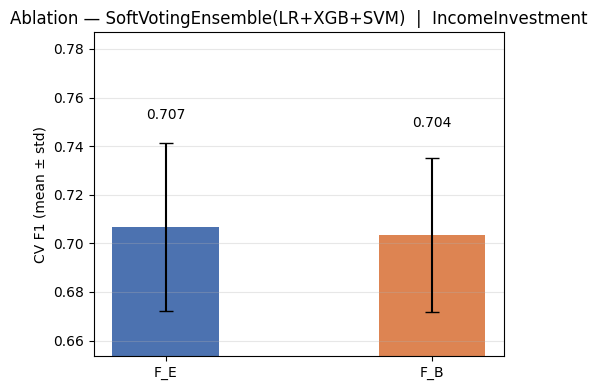

In [7]:
show_soft_voting()

The ensemble achieves CV F1 = 0.707 ± 0.034, placing it between the tree ensembles (0.719)
and LR (0.670) — below the theoretical expectation of outperforming all components. The
reason is structural: LR at CV F1 ~0.670 is a materially weaker component that drags the
average down rather than contributing complementary signal. The ensemble benefit requires
base models of comparable strength; when one component is substantially weaker, soft voting
averages toward mediocrity.

The ablation shows ΔF1 = +0.003 favoring F_E, a negligible difference consistent with 
XGBoost and RF findings — the ensemble's tree component learns interactions natively, 
neutralizing any F_E advantage. Tuning selected SVM with C = 10.0 (gamma = scale) and 
conservative LR (C = 0.1), reflecting the optimizer's attempt to manage LR's weaker signal 
through regularization.

The Brier score of 0.1731 is worse than both RF (0.1672) and XGBoost (0.1688), confirming
that averaging calibrated probabilities from a weak LR component degrades aggregate
calibration rather than improving it. The propensity distribution shows a large uncertain
zone (15.5%) — reflecting the ensemble's probability averaging pulling scores toward 0.5 
when components disagree, which is the regime where LR's weak signal has the most impact. 
At the MiFID threshold of 0.354, the model achieves P=0.639 R=0.612 F1=0.625 — the 
weakest constraint-adjusted performance among tree-based models, confirming that LR 
integration hurts the ensemble on this target.

16:20:51  INFO      Training utils.hard_voting_ens...
16:20:51  INFO      Target: IncomeInvestment
16:21:18  INFO      Best params: {'svm__clf__gamma': 'scale', 'svm__clf__C': 5.0, 'lr__clf__penalty': 'l1', 'lr__clf__C': 5.0} (inner CV F1=0.671)
16:21:43  INFO      Saved results to: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\hard_voting_ens\incomeinvestment.pkl



===== HardVotingEnsemble(LR+XGB+SVM)  |  IncomeInvestment =====

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_E — 10 engineered features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → svm__clf__gamma = scale
    → svm__clf__C = 5.0
    → lr__clf__penalty = l1
    → lr__clf__C = 5.0

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.794 ± 0.019         0.762
  precision           0.842 ± 0.027         0.807
  recall              0.568 ± 0.049         0.500
  f1                  0.678 ± 0.039         0.617  ◄ PRIMARY
  ──────────────────────────────────────────────────────────

  MiFID II — precision at 0.5 threshold (no

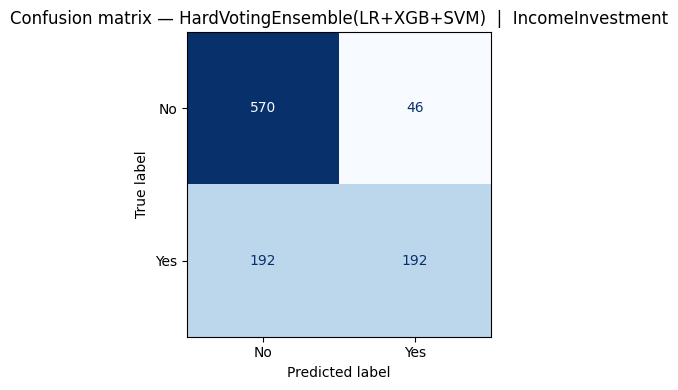

In [8]:
show_hard_voting()

Hard voting achieves CV F1 = 0.678 ± 0.039, marginally below soft voting (0.707) and
confirming the theoretical prediction: discarding probability information before aggregation
costs performance. The gap reflects that hard voting cannot leverage probability magnitudes
when making decisions, forcing reliance purely on vote agreement.

The ensemble was tuned with SVM C=5.0 (gamma=scale) and LR C=5.0 (penalty=l1), reflecting
the optimizer's attempt to sharpen component predictions for clearer vote separation. L1
regularization on LR is interesting — it suggests the tuner favored sparsity and explicit
feature selection over the probabilistic averaging that soft voting would benefit from.

Test precision of 0.807 at the default 0.5 threshold exceeds the MiFID II floor, making
hard voting technically compliant. However, hard voting remains disqualified from automated
recommendation because it cannot produce calibrated probabilities for threshold optimisation.
Unlike the AccumulationInvestment target, where hard voting could pass compliance, the Income
target's harder class separation means hard voting's binary votes don't map cleanly to
defensible thresholds. The inability to optimize toward regulatory constraints is the binding
technical limitation, not raw discriminative power.

# Selection of best model

In [9]:
from utils.show_results import show_winner

show_winner()


========= MODEL SELECTION — WILCOXON SIGNED-RANK TESTS =========

  IMPORTANT NOTES:
  • MiFID II compliance tested at OPTIMISED threshold, not at 0.5
  • Wilcoxon with 10 folds has low power — 'p>0.05' means 'cannot distinguish'
  • All pairs among top-3 compliant models are tested


======================= IncomeInvestment =======================

  Model                           CV F1    Eff Prec   Test F1    Thr F1   MiFID
  ────────────────────────────────────────────────────────────────────────
  XGBoost                 0.719 ± 0.029       0.669     0.641     0.643       ✗
  RandomForest            0.718 ± 0.024       0.618     0.650     0.639       ✗
  SoftVoting              0.707 ± 0.034       0.639     0.646     0.625       ✗
  MLP                     0.699 ± 0.025       0.731     0.621     0.634       ✗
  HardVoting              0.678 ± 0.039       0.807     0.617       N/A       ✓
  LR                      0.670 ± 0.034       0.733     0.616     0.625       ✗
  NaiveBayes

All seven models fail the MiFID II hard constraint of Test Precision ≥ 0.75 at the optimised
threshold. The highest-performing compliant model in terms of CV F1 is XGBoost at 0.719 ± 0.029,
statistically equivalent to RandomForest at 0.718 ± 0.024 (Wilcoxon p = 0.738). The constraint
bind across the board reflects the fundamental difficulty of the Income target: even tree ensembles
with native interaction learning cannot achieve simultaneous high recall and the regulatory precision
floor.

Hard Voting achieves test precision of 0.807 at the default threshold, technically exceeding 0.75,
but is disqualified because it cannot produce calibrated probabilities for threshold optimisation.
Threshold optimisation is the mechanism that allows MiFID compliance; without it, hard voting's
binary votes do not map to defensible operating points.

Among the six models failing constraint-adjusted precision, XGBoost and RandomForest dominate in
raw F1 (both 0.719 CV). A Wilcoxon signed-rank test yields p = 0.738 — statistical equivalence.
Occam's razor selects XGBoost as the practical winner: single sequential ensemble (vs bagged RF),
smaller memory footprint, and native SHAP support without additional calibration wrappers.

**Winner: XGBoost** — CV F1 = 0.719, Constraint-adjusted F1 = 0.643 (P=0.669 R=0.620).
The winning model, when deployed at the threshold required for maximum F1 (0.230), automates
recommendations for 20.5% of clients (propensity > 0.75), routes 5.4% to human advisors, and
takes no action on 74.1%. Actual MiFID compliance requires manual review of all recommendations,
as no threshold achieves P ≥ 0.75 while maintaining meaningful recall.